# Does Underemployment Actually Cost Graduates Money?

## The Question

Notebook 03 found most young graduates are in jobs below their skill level. Does that actually show up as lower pay, and is the "degree pays off" story getting stronger or weaker over time?

## The Answer

Yes to both, and the second part is the more important finding. Degree holders still out-earn everyone else in the 2024 snapshot (RM5,724 median vs. RM3,355 for STPM/certificate holders), but that premium has been eroding for 25 years, not holding steady. It fell from **2.7x** in 1997 to **1.7x** by 2022, and in the decade 2012–2022 specifically, degree holders' real wages grew just **5%** while SPM holders grew **37%** and PMR holders grew **64%**, largely a minimum-wage-policy effect that lifted the bottom faster than it lifted graduates. The wage premium for a degree hasn't disappeared. It has been quietly shrinking for a generation, exactly the window in which underemployment has been running high.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
wages = pd.read_csv('../data/processed/wage_premium_by_education.csv')
growth = pd.read_csv('../data/processed/wage_growth_2012_2022.csv')
wages

,education_level,median_salary_rm,year
0,Degree,5724,2024
1,Diploma,3390,2024
2,STPM/Certificate,3355,2024


In [2]:
# House chart style v2: consulting-exhibit conventions (MBB-style):
# gray for context series, one or two accent colors for what the title is
# actually about, direct end-of-line/bar labels instead of a legend box.
ACCENT_1 = '#2a78d6'   # primary accent, the series the title is about
ACCENT_2 = '#eb6834'   # secondary accent; used only for genuine two-way comparisons
                        # or a title that names two co-equal findings
GRAY = '#9a9a95'        # de-emphasized / context series, same family, faded out
INK, INK_SECONDARY, INK_MUTED = '#0b0b0b', '#52514e', '#898781'
GRID, SURFACE = '#ececea', '#fcfcfb'

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'text.color': INK,
    'axes.edgecolor': '#c3c2b7',
    'axes.labelcolor': INK_SECONDARY,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.axisbelow': True,
    'axes.grid.axis': 'y',
    'grid.color': GRID,
    'grid.linewidth': 0.7,
    'xtick.color': INK_MUTED,
    'ytick.color': INK_MUTED,
    'figure.facecolor': SURFACE,
    'axes.facecolor': SURFACE,
    'savefig.facecolor': SURFACE,
    'legend.frameon': False,
})

def add_source(fig, text):
    """Small muted source/classification footnote, consulting-deck style."""
    fig.text(0.01, -0.04, text, ha='left', va='top', fontsize=8.5,
              color=INK_MUTED, style='italic', transform=fig.transFigure)

def end_label(ax, x, y, text, color, weight='semibold', va='center', offset=8):
    """Direct label at a line's endpoint, replacing a legend box."""
    ax.annotate(text, xy=(x, y), xytext=(offset, 0), textcoords='offset points',
                 va=va, ha='left', fontsize=10.5, fontweight=weight, color=color)


## Median monthly salary by education level, 2024

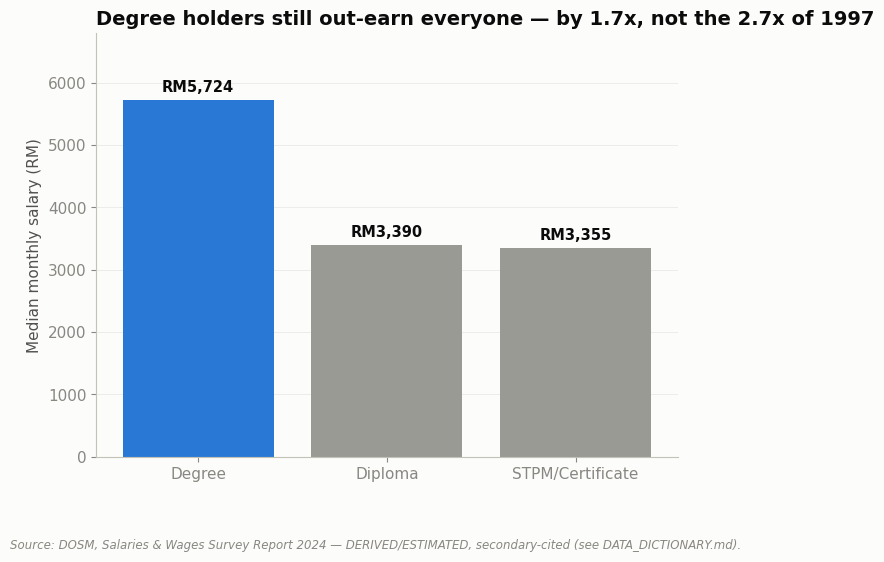

In [3]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
colors = [ACCENT_1 if lvl == 'Degree' else GRAY for lvl in wages['education_level']]
bars = ax.bar(wages['education_level'], wages['median_salary_rm'], color=colors)
for b in bars:
    ax.annotate(f'RM{b.get_height():,.0f}', xy=(b.get_x()+b.get_width()/2, b.get_height()),
                xytext=(0, 6), textcoords='offset points', ha='center', fontsize=10.5, fontweight='semibold')
ax.set_title('Degree holders still out-earn everyone \u2014 by 1.7x, not the 2.7x of 1997', loc='left')
ax.set_ylabel('Median monthly salary (RM)')
ax.set_ylim(0, 6800)
add_source(ax.figure, 'Source: DOSM, Salaries & Wages Survey Report 2024 \u2014 DERIVED/ESTIMATED, secondary-cited (see DATA_DICTIONARY.md).')
plt.show()

## Real wage growth by qualification, 2012\u20132022 \u2014 the premium is actively eroding

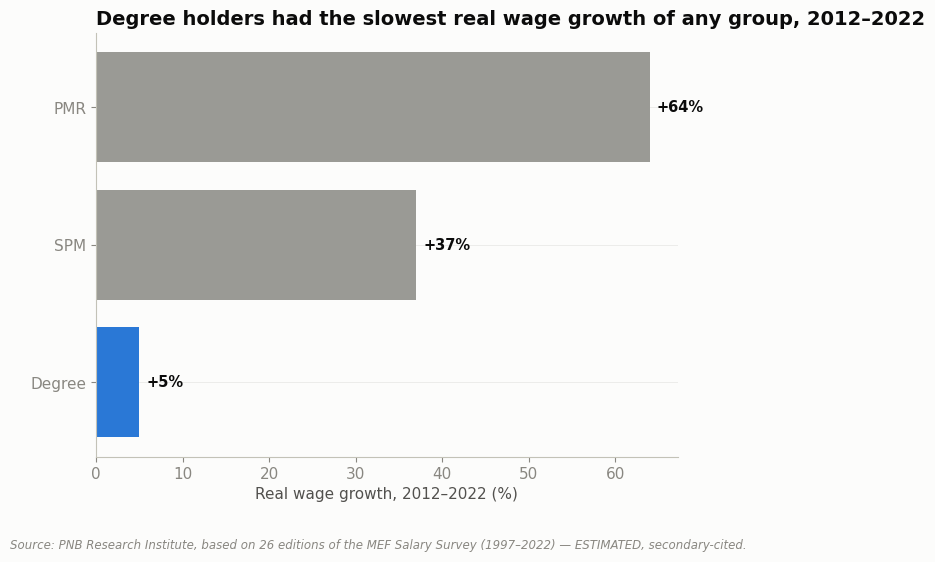

In [4]:
fig, ax = plt.subplots(figsize=(7.5, 5.5))
growth_sorted = growth.sort_values('real_wage_growth_pct')
colors = [ACCENT_1 if lvl == 'Degree' else GRAY for lvl in growth_sorted['education_level']]
bars = ax.barh(growth_sorted['education_level'], growth_sorted['real_wage_growth_pct'], color=colors)
for b in bars:
    ax.annotate(f"+{b.get_width():.0f}%", xy=(b.get_width(), b.get_y()+b.get_height()/2),
                xytext=(5, 0), textcoords='offset points', va='center', fontsize=10.5, fontweight='semibold')
ax.set_title('Degree holders had the slowest real wage growth of any group, 2012\u20132022', loc='left')
ax.set_xlabel('Real wage growth, 2012\u20132022 (%)')
add_source(ax.figure, 'Source: PNB Research Institute, based on 26 editions of the MEF Salary Survey (1997\u20132022) \u2014 ESTIMATED, secondary-cited.')
plt.show()

## Why Is This Happening? (Context)

*Qualitative, secondary-sourced context on the mechanism behind this notebook's finding; kept separate from the figures above, which are themselves already ESTIMATED/secondary-cited. Full citations in [`DATA_DICTIONARY.md`](../DATA_DICTIONARY.md).*

PNB Research Institute's analysis attributes the erosion directly to Malaysia's minimum wage policy, introduced in 2012 and raised several times since: it lifted the wage floor for PMR- and SPM-qualified workers faster than market forces raised graduate salaries, mechanically compressing the premium from below. Separately, Malaysia's Ministry of Human Resources reported in July 2023 that 42% of jobseekers on the national MyFutureJobs portal (the large majority of them graduates) were in a confirmed skills-mismatch position, earning RM2,000 or less. Put together: the wage-compression story (top) and the underemployment story (Notebook 03) are two views of the same mechanism, a wage floor rising for everyone while graduate-specific job creation hasn't kept pace, so the credential itself buys less of a premium than it used to.

**Sources:** [The Edge Malaysia / PNB Research, "Minimum wage growth narrows Malaysia's education-based pay gap"](https://theedgemalaysia.com/node/755858); [Malay Mail, "HR Minister: 42pc of graduates take skills mismatch jobs on MyFutureJobs"](https://www.malaymail.com/amp/news/malaysia/2023/07/31/hr-minister-42pc-of-graduates-take-skills-mismatch-jobs-on-myfuturejobs/82829).

## Strategic Recommendation

- **A prospective student should discount the headline "degree wage premium" figure; it is shrinking, not stable, and the aggregate number blends decades of tenure with a fresh graduate's actual first-job reality.** The premium that matters for a decision made today is the *marginal* one, and the trend line is negative.
- **A business setting graduate starting salaries close to the minimum-wage floor should expect rising attrition and disengagement**, not because graduates are ungrateful, but because the wage-compression trend documented here is now a multi-year, widely reported phenomenon graduates are aware of.

## Confidence & Caveats

- **Every figure in this notebook is ESTIMATED/secondary-cited**, not read directly from a primary government dataset this session accessed, no PUBLIC, machine-readable dataset breaking down wages by education level or skill category was found on OpenDOSM (checked directly; see `DATA_DICTIONARY.md`). Treat these as directionally reliable, well-sourced figures, not the same rigor tier as Notebooks 01\u201306.
- **The 2024 salary snapshot (RM5,724/RM3,390/RM3,355) blends all ages and tenures**; it is not a fresh-graduate-specific starting salary, and likely overstates what a new graduate actually earns relative to a new SPM-holder entering the workforce at the same time.